# Clone model

In [ ]:
!git clone https://github.com/real2fish/CSL.git

Cloning into 'CSL'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (65/65), done.
Receiving objects: 100% (68/68), 197.21 KiB | 5.06 MiB/s, done.
remote: Total 68 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (34/34), done.


In [ ]:
import sys
if not "CSL" in sys.path:
  sys.path += ["CSL"]

!cd CSL

In [ ]:
# important if we want to replicate the findings in the paper
# particularly for notebooks like Colab.
import os

os.rename('/content/CSL/Multivariate_ts', './Multivariate_ts')

os.listdir()

['.config', 'CSL', 'Multivariate_ts', 'sample_data']

In [ ]:
!git clone https://github.com/stephanielees/CSL_sales_cluster.git

Cloning into 'CSL_sales_cluster'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 24 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 630.45 KiB | 39.40 MiB/s, done.
Resolving deltas: 100% (6/6), done.


## Installing dependent libraries

In [ ]:
!pip install ucimlrepo
!pip install tsaug
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.7/372.7 kB 31.4 MB/s eta 0:00:00


# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CSL_sales_cluster.utils import ts_scatterplot, plot_dataset_in_clusters
import re
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import torch
from ucimlrepo import fetch_ucirepo
import tsaug
import CSL
from CSL import train, blocks, utils, CSL_AD, UEA

In [ ]:
# reproduce the findings on the paper
# UEA.evaluate_UEA('BasicMotions')

# The use case data

In [ ]:
sales_transactions_weekly = fetch_ucirepo(id=396)

# data (as pandas dataframes)
X = sales_transactions_weekly.data.features

In [ ]:
X.shape

(811, 106)

In [ ]:
X.columns[52:54]

Index(['MIN', 'MAX'], dtype='object')

In [ ]:
X_norm = StandardScaler().fit_transform(X.iloc[:, :52])

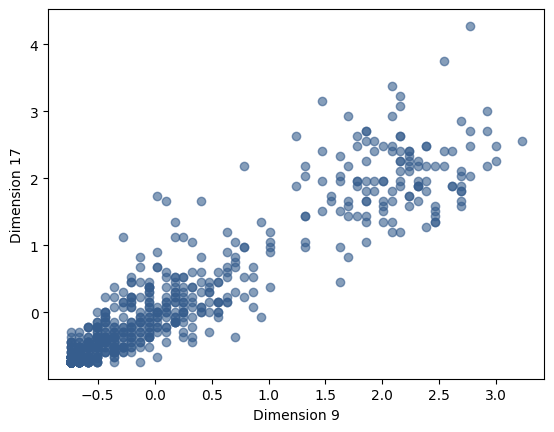

In [ ]:
dim1 = 9
dim2 = 17
ts_scatterplot(X_norm, dim1, dim2)

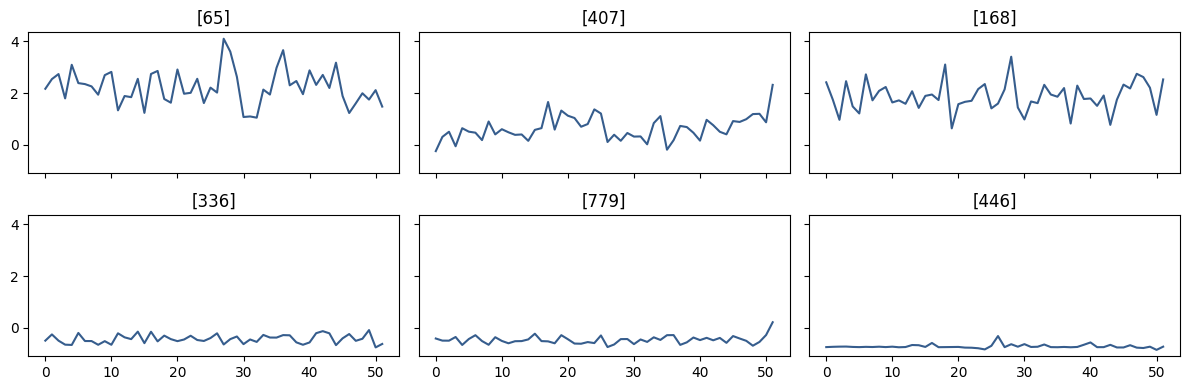

In [ ]:
_, axs = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=True, tight_layout=True, figsize=(12, 4))
rng = np.random.default_rng()
for i, ax in enumerate(axs.flat):
  item_id = rng.choice(811, 1)
  ax.plot(np.arange(52),
          X_norm[item_id].T,
          color='#365d8d')
  ax.set_title(item_id);

# Time series augmentation

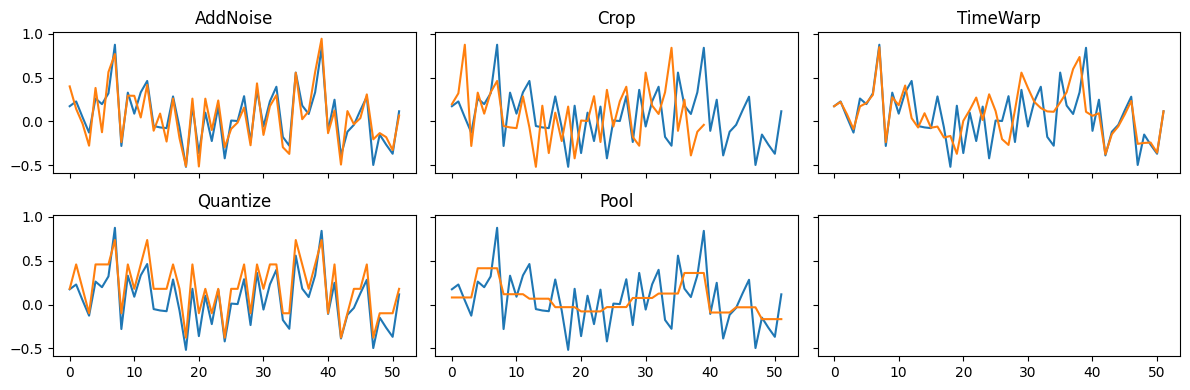

In [ ]:
jitter = tsaug.AddNoise(loc=0.0, seed=1)
crop = tsaug.Crop(size=40, seed=1)
warp = tsaug.TimeWarp(seed=1)
quant = tsaug.Quantize(n_levels=5, seed=1)
pool = tsaug.Pool(size=4, seed=1)
pat = r'[A-Z][a-zA-Z]*'

_, axs = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=True, tight_layout=True, figsize=(12, 4))
for ax, aug in zip(axs.flat, [jitter, crop, warp, quant, pool]):
  ax.plot(X_norm[0])
  ax.plot(aug.augment(X_norm[0]))
  ax.set_title(re.findall(pat, str(aug))[0]);

# Find shapelets with Contrastive Shapelet Learning

In [ ]:
# X_norm = X_norm.to_numpy()
X_norm = np.expand_dims(X_norm, 1)
X_norm.shape

(811, 1, 52)

In [ ]:
shapelets_length_v = {k:24 for k in np.linspace(0.1*X_norm.shape[2], 0.5*X_norm.shape[2], 8, dtype='int16')}
shapelets_length_v

{np.int16(5): 24,
 np.int16(8): 24,
 np.int16(11): 24,
 np.int16(14): 24,
 np.int16(17): 24,
 np.int16(20): 24,
 np.int16(23): 24,
 np.int16(26): 24}

In [ ]:
csl = train.LearningShapeletsCL({5:24, 40:24},
                                loss_func=torch.nn.CrossEntropyLoss(), dist_measure='cosine',
                                num_classes=7, l3=0.5, l4=0.5, alpha=0.5,
                                verbose=1)

In [ ]:
csl.set_optimizer(torch.optim.SGD(csl.model.parameters(), lr=1e-2))

In [ ]:
csl.train(X_norm, batch_size=32, epochs=5)

Loss: [13.513294219970703, 0, 3.3796494007110596, 25.750102996826172, 0]: 100%|██████████| 5/5 [00:11<00:00,  2.32s/it]


[[18.779558181762695, 0, 9.399080276489258, 31.659276962280273, 0],
 [18.759119033813477, 0, 10.998329162597656, 29.9011173248291, 0],
 [17.877918243408203, 0, 9.456786155700684, 29.814735412597656, 0],
 [17.16278839111328, 0, 7.251447677612305, 30.437549591064453, 0],
 [17.8577880859375, 0, 9.599590301513672, 29.139537811279297, 0],
 [16.268051147460938, 0, 8.767123222351074, 28.814762115478516, 0],
 [16.915969848632812, 0, 8.042823791503906, 29.12537384033203, 0],
 [18.198280334472656, 0, 9.681957244873047, 29.613140106201172, 0],
 [17.745338439941406, 0, 9.452033996582031, 29.468210220336914, 0],
 [18.12396240234375, 0, 9.05742073059082, 29.601978302001953, 0],
 [17.848979949951172, 0, 9.59776496887207, 29.166322708129883, 0],
 [18.14761734008789, 0, 8.689385414123535, 29.960224151611328, 0],
 [17.211448669433594, 0, 7.9684343338012695, 29.693613052368164, 0],
 [17.8188419342041, 0, 8.069857597351074, 29.388080596923828, 0],
 [17.23407745361328, 0, 7.4326252937316895, 29.13506126403

In [ ]:
# to study the layers in the CSL model
csl.model

LearningShapeletsModel(
  (shapelets_blocks): ShapeletsDistBlocks(
    (blocks): ModuleList(
      (0-1): 2 x MaxCosineSimilarityBlock(
        (relu): ReLU()
      )
    )
  )
  (linear): Linear(in_features=48, out_features=7, bias=True)
  (projection): Sequential(
    (0): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (projection2): Sequential(
    (0): Linear(in_features=48, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [ ]:
X_transform = csl.transform(X_norm).numpy()
X_transform.shape

(811, 48)

In [ ]:
X_norm.shape

(811, 1, 52)

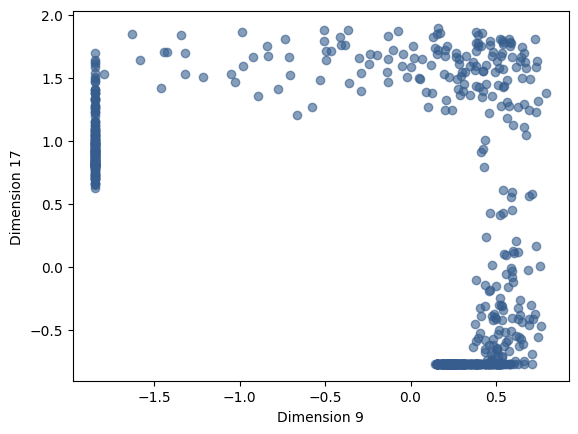

In [ ]:
dim1 = 9
dim2 = 17

ts_scatterplot(X_transform, dim1, dim2)

## new part: extracting the shapelets (thanks to @davegoel1560 from youtube)

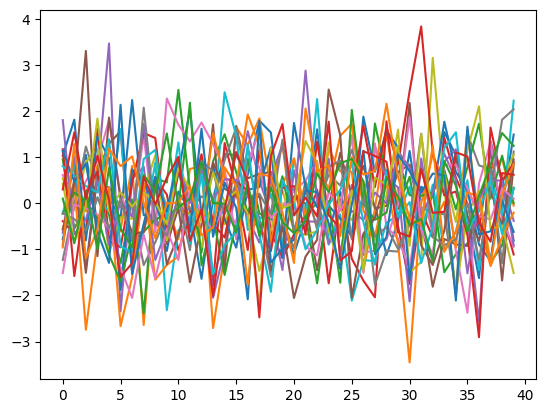

In [ ]:
plt.plot(csl.model.shapelets_blocks.blocks[1].shapelets[0].cpu().detach().numpy().T);
# csl.model.shapelets_blocks.blocks[1].shapelets[0].shape

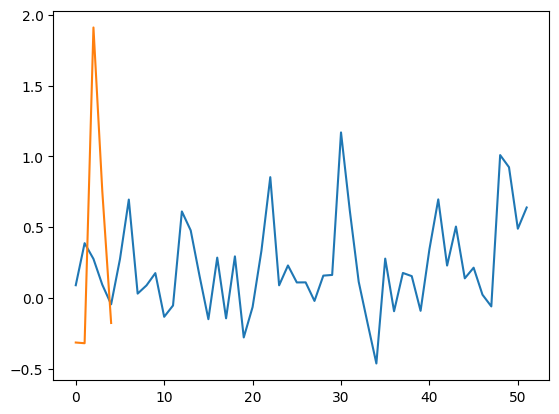

In [ ]:
maybe_shapelets = csl.model.shapelets_blocks.blocks[0].shapelets[0].cpu().detach().numpy()
plt.plot(X_norm[543,0,:], label='real data')
plt.plot(maybe_shapelets[17], label='shapelet');

# Clustering

In [ ]:
from sklearn.cluster import KMeans, HDBSCAN

km = KMeans(n_clusters=3, random_state=1)
km.fit(X_transform)

hdb = HDBSCAN(metric='cosine')
hdb.fit(X_transform)

HDBSCAN(metric='cosine')

In [ ]:
lab_km = km.predict(X_transform)
lab_hdb = hdb.labels_

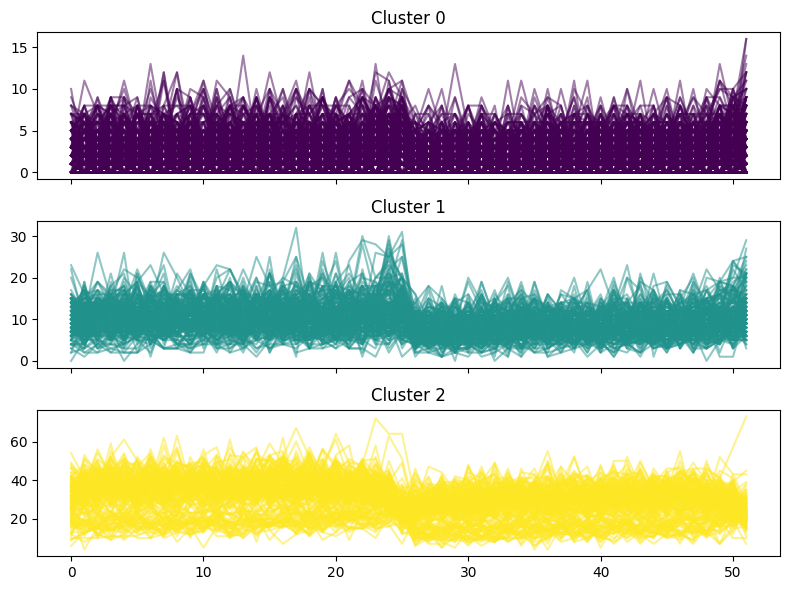

(array([0, 1, 2], dtype=int32), array([478, 170, 163]))

In [ ]:
plot_dataset_in_clusters(X.iloc[:, :52].values, lab_km, sharey_=False, figsize=(8,6))
np.unique(lab_km, return_counts=True)

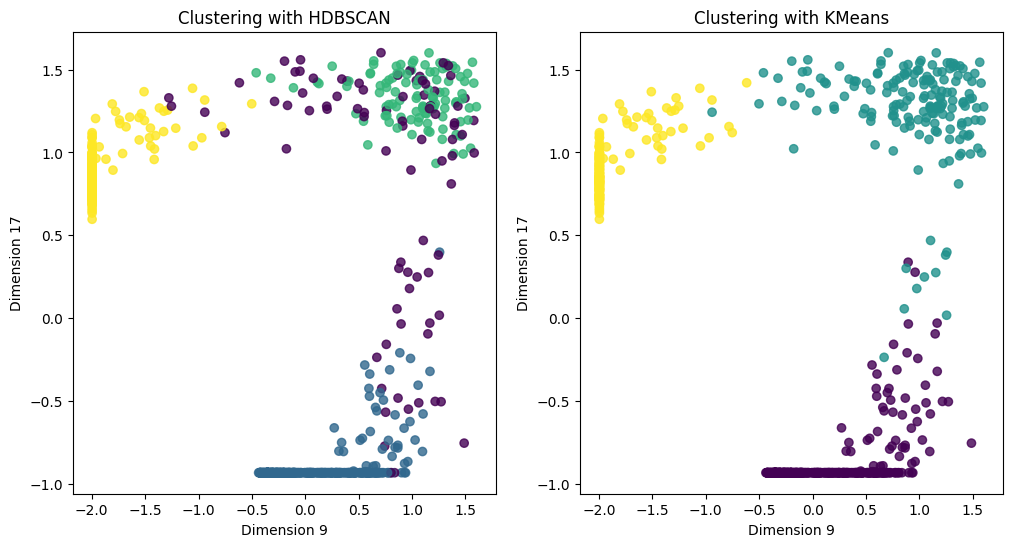

In [ ]:
#plot the data in two dimensions
dim1 = 9
dim2 = 17
_, axs = plt.subplots(1, 2, figsize=(12, 6))
for ax, label_arr, label_name in zip(axs, [lab_hdb, lab_km], ['HDBSCAN', 'KMeans']):
  ax.scatter(X_transform[:, dim1], X_transform[:, dim2], c=label_arr, cmap='viridis', alpha=0.8)
  ax.set_xlabel(f'Dimension {dim1}')
  ax.set_ylabel(f'Dimension {dim2}')
  ax.set_title(f'Clustering with {label_name}');

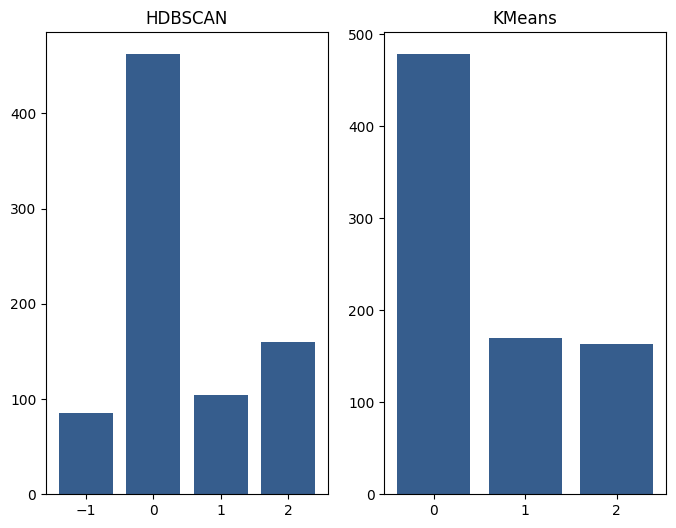

In [ ]:
class_label_km, counts_km = np.unique(lab_km, return_counts=True)
class_label_hdb, counts_hdb = np.unique(lab_hdb, return_counts=True)
_, axs = plt.subplots(1, 2, figsize=(8, 6))
axs[0].bar(class_label_hdb, counts_hdb, color='#365d8d')
axs[0].set_title('HDBSCAN')
axs[1].bar(class_label_km, counts_km, color='#365d8d')
axs[1].set_title('KMeans');

In [ ]:
print(silhouette_score(X_transform, lab_km, metric='cosine'))
mask = lab_hdb != -1
print(silhouette_score(X_transform[mask], lab_hdb[mask], metric='cosine'))

0.7821468
0.8253352
